In [1]:
# df similar to what you have
import pandas as pd
import json
import pandas as pd
import matplotlib.pyplot as plt

with open('patient_rename.txt') as f:
    data = f.read()
js = json.loads(data)
print(js)
reversed_js = {value: key for key, value in js.items()}

with open('patient_renumber.txt') as f:
    data = f.read()
js_number = json.loads(data)
print(js_number)


pt_ch_mapping ={
        # "EC130_513": [3],
        "EC130": [1,13],
        # "EC131_513": [273, 274, 275, 276, 282, 283, 284],
        # "EC131_513": [273, 275, 282, 284],
        "EC133": [282, 291, 292, 293],
        "EC135": [303, 304],
        "EC137": [258, 260, 271, 272],
        # "EC143_513": [327, 329, 336, 338, 339],
        "EC143": [329, 336, 338, 339],
        # "EC157_513": [323, 331, 332],
        "EC157": [321, 323, 331, 332],
        "EC162": [85, 86, 99, 100],
        "EC175": [301, 302],
        "EC183": [290],
        "EC186": [299, 300, 301],
        "EC187": [309, 310, 311],
        # "EC191_513": [2, 3, 4, 11, 12, 13, 65],
        "EC191": [2, 3, 11, 12],
        "EC196": [300, 301, 303],
        # "EC219_513": [399, 400, 401, 402, 403],
        "EC219": [399, 400, 401, 403],
        "EC220": [53, 54, 76, 77],
        "EC221": [376, 377],
        # "EC222_513": [267,268,269,270,277],
        "EC222": [267, 268, 269, 270],
        }

# df = pd.read_csv('auto_label_stats.txt', sep=" ", header=None, names=["Patient","Ripple", "Spike","Ripple_num", "Spike_num"], index_col=0)
df = pd.read_csv('auto_label_stats_new.txt', sep=" ", header=None, names=["Patient","Ripple", "Spike","Ripple_num", "Spike_num"], index_col=0)

df['Total_Number'] = df['Ripple_num'] + df['Spike_num']

idx = list(df.index)
for i in range(len(idx)):
    idx[i] = js[idx[i]]
df = df.rename(js)
df = df[[ "Spike","Ripple"]]




{'EC186': 'Pt 1', 'EC222': 'Pt 2', 'EC133': 'Pt 3', 'EC191': 'Pt 4', 'EC196': 'Pt 5', 'EC175': 'Pt 6', 'EC220': 'Pt 7', 'EC221': 'Pt 8', 'EC157': 'Pt 9', 'EC135': 'Pt 10', 'EC219': 'Pt 11', 'EC162': 'Pt 12', 'EC143': 'Pt 13', 'EC137': 'Pt 14', 'EC187': 'Pt 15', 'EC130': 'Pt 16', 'EC183': 'Pt 17'}
{'EC130': 1465, 'EC133': 1220, 'EC135': 344, 'EC137': 7222, 'EC143': 881, 'EC157': 4747, 'EC162': 2398, 'EC175': 518, 'EC186': 1710, 'EC183': 220, 'EC187': 1315, 'EC191': 642, 'EC196': 594, 'EC219': 2015, 'EC220': 2572, 'EC221': 859, 'EC222': 3125}


['', '', '0.2%', '0.4%', '1.2%', '1.8%', '1.8%', '2.6%', '3.9%', '4.1%', '4.2%', '5.0%', '8.6%', '9.7%', '13.1%', '15.8%', '47.2%']
['100.0%', '100.0%', '99.8%', '99.6%', '98.8%', '98.2%', '98.2%', '97.4%', '96.1%', '95.9%', '95.8%', '95.0%', '91.4%', '90.3%', '86.9%', '84.2%', '52.8%']


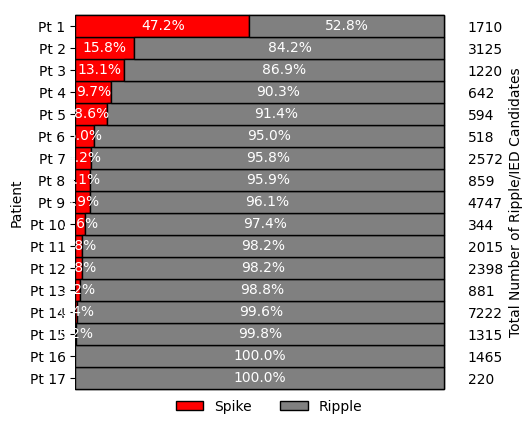

In [2]:
df = df.sort_values("Ripple", ascending=False)
totals = df.sum(axis=1)
# totals = df.iloc[:, :2].sum(axis=1)

# calculate the percent for each row
percent = df.div(totals, axis=0).mul(100).round(4)

# create the plot
# fig, ax1 = plt.subplots(figsize=(6, 5))
fig, ax1 = plt.subplots(figsize=(5, 5))
# percent.plot(kind='barh', ax=ax1, stacked=True, figsize=(6, 5), color=['red','gray'], xticks=[], width=1.0, edgecolor='black')
percent.plot(kind='barh', ax=ax1, stacked=True, figsize=(5, 5), color=['red','gray'], xticks=[], width=1.0, edgecolor='black')

# # move the legend
ax1.get_legend().remove()
ax2 = ax1.twinx() # Creating the right hand side y axis
# percent.plot(kind='barh', ax=ax2, stacked=True, figsize=(6, 5), color=[  'red','gray'], xticks=[], width=1.0, edgecolor='black')
percent.plot(kind='barh', ax=ax2, stacked=True, figsize=(5, 5), color=['red','gray'], xticks=[], width=1.0, edgecolor='black')

# ax2.set_ylim(1, len(df))
# ax2.set_ylabel('Value 2', color='orange')
ticks = ax1.get_yticks()
tick_labels = ax1.get_yticklabels()

# Set the same ticks for the second y-axis, but scale them to match Value2
ax2.set_yticks(ticks)  # Set y-ticks to match the first y-axis
ax2.set_yticklabels(df.index)  # Scale labels to match Value2
ax2.get_legend().remove()

ax2.tick_params(pad=-18)

ax2.set_yticks(range(0, len(df)))
idx = list(df.index)
list_number = []
for i in range(len(idx)):
    each_number = js_number[reversed_js[idx[i]]]
    list_number.append(each_number)
ax2.set_yticklabels([("%s"%str(i)) for i in list_number]) 
ax2.yaxis.set_tick_params(pad=0.05) 
ax2.set_ylabel('Total Number of Ripple/IED Candidates')

ax2.spines[['top', 'bottom', 'left', 'right']].set_visible(False)

ax2.legend(loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2, frameon=False)

# remove ticks
ax2.tick_params(right=False, bottom=False)
# remove all spines
ax1.spines[['top', 'bottom', 'left', 'right']].set_visible(False)

# iterate through each container
for c in ax2.containers:
    
    # custom label calculates percent and add an empty string so 0 value bars don't have a number
    labels = [f'{w:0.1f}%' if (w := v.get_width()) > 0 else '' for v in c]
    print(labels)
    
    # add annotations
    ax2.bar_label(c, labels=labels, label_type='center', padding=0.3, color='w')
    # ax.bar_label(c, labels=labels, label_type='edge', padding= 3, color='k')

# ax2.set_title("Human Labled Ripple/Spike Ratio")

# ax2.figure.savefig('auto_label_stats_paper.png', dpi=1200)

